# Loan Risk Prediction using Naive Bayes

---
<p align="justify">This analysis aims to develop a predictive model for loan risk assessment using a machine learning approach. It leverages a dataset containing information about loan applicants, including demographics, financial history, and loan details. By applying the Naive Bayes algorithm, the model learns patterns from historical data to predict the likelihood of loan approval or rejection for new applicants.

<p align="justify">The primary objective of this analysis is to build a reliable model that accurately predicts the risk associated with loan applications. This will enable financial institutions to make informed lending decisions and mitigate potential losses by identifying high-risk applicants. By automating the risk assessment process, the model aims to improve efficiency and consistency in loan approvals.

---



## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

## Load Data

In [2]:
df = pd.read_csv('/content/drive/MyDrive/datasets/loan_risk_data.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Data Cleaning & Preprocessing

In [4]:
# Drop Loan_ID
df.drop('Loan_ID', axis=1, inplace=True)

In [5]:
# Fill missing values
df.fillna({
    'Gender': df['Gender'].mode()[0],
    'Married': df['Married'].mode()[0],
    'Dependents': df['Dependents'].mode()[0],
    'Self_Employed': df['Self_Employed'].mode()[0],
    'LoanAmount': df['LoanAmount'].median(),
    'Loan_Amount_Term': df['Loan_Amount_Term'].mode()[0],
    'Credit_History': df['Credit_History'].mode()[0]
}, inplace=True)

## Define X and Y

In [6]:
# Separate features (X) and target (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

## Split Data Into Train and Test Sets

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Convert Categorical Features to Numerical

In [8]:
encoder = LabelEncoder()

# List of categorical columns to encode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

# Loop through each categorical column and apply Label Encoding
for col in categorical_cols:
    if col in X_train.columns:  # Check if column exists in X_train
        X_train[col] = encoder.fit_transform(X_train[col])
    if col in X_test.columns:  # Check if column exists in X_test
        X_test[col] = encoder.transform(X_test[col])

## Train the Model

In [9]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

## Make Prediction

In [10]:
y_pred = model.predict(X_test)

## Model Evaluation

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7837837837837838


## Confusion Matrix

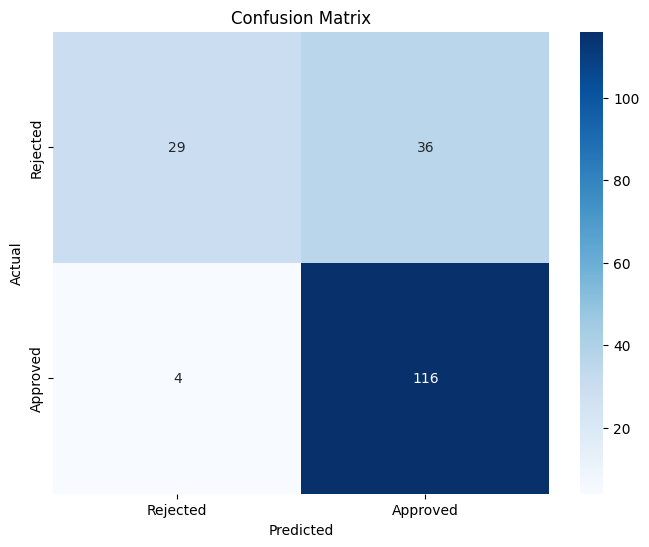

In [12]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Rejected', 'Approved']

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Findings

<p align="justify">The analysis demonstrates the potential of using Naive Bayes algorithm for loan risk prediction. The model achieved an accuracy of 0.784, indicating the overall correctness of its predictions. The confusion matrix provides a detailed breakdown of the model's performance and insights into the types of errors it makes. By applying the model, financial institutions can automate the risk assessment process and make informed lending decisions, which can help to mitigate potential losses by identifying high-risk applicants. This automated approach improves efficiency and consistency in loan approvals, streamlining the lending process.

<p align="justify">While the model achieved reasonable accuracy, further exploration of feature engineering and hyperparameter tuning could potentially improve its performance. The quality and representativeness of the training data are crucial for building a robust and reliable model, so ensuring data accuracy and completeness is essential. The model's predictions should be interpreted within the specific business context and risk appetite of the financial institution.



---



## *BONUS: Gradio UI Implementation

In [13]:
!pip install gradio

In [14]:
# Function to make predictions
def predict_loan_status(Gender, Married, Dependents, Education, Self_Employed, Property_Area, LoanAmount, Loan_Amount_Term, Credit_History):
    input_data = np.array([[Gender, Married, Dependents, Education, Self_Employed, Property_Area, LoanAmount, Loan_Amount_Term, Credit_History]])
    prediction = model.predict(input_data)
    result = 'Approved' if prediction == 1 else 'Rejected'
    return result

In [ ]:
import gradio as gr

iface = gr.Interface(
    fn=predict_loan_status,
    inputs = [
        gr.Dropdown(["Male", "Female"], label="Gender"),
        gr.Dropdown(["Married", "Unmarried"], label="Married"),
        gr.Dropdown(["0", "1", "2+"], label="Dependents"),
        gr.Dropdown(["Graduate", "Not Graduate"], label="Education"),
        gr.Dropdown(["Self Employed", "Not Self Employed"], label="Self Employed"),
        gr.Dropdown(["Urban", "Semiurban", "Rural"], label="Property Area"),
        gr.Number(label="LoanAmount"),
        gr.Dropdown(["360", "180", "240"], label="Loan Amount Term"),
        gr.Slider(minimum=0.0, maximum=1.0, label="Credit History", step=0.1)
    ],
    outputs="text",
    title="Loan Risk Prediction",
    description="Enter the details to predict loan risk.",
    live=True
    )

iface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7950109c9a069183fd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
